In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
from profiling import *

DATASET_PATH = "../data/datasets/train.parquet"

In [2]:
df = load_dataset(DATASET_PATH)
ov = dataset_overview(df)
print(f"Rows: {ov['n_rows']:,}  |  Sequences: {ov['n_sequences']:,}  "
      f"|  Steps/seq: {ov['steps_per_sequence']}  "
      f"|  Memory: {ov['memory_mb']} MB")

nan_cols = {k: v for k, v in ov["nan_counts"].items() if v > 0}
print("Columns with NaNs:", nan_cols if nan_cols else "none")

Rows: 10,721,000  |  Sequences: 10,721  |  Steps/seq: 1000  |  Memory: 1564.3 MB
Columns with NaNs: none


In [3]:
ov

{'n_rows': 10721000,
 'n_sequences': 10721,
 'steps_per_sequence': 1000,
 'pct_need_prediction': np.float64(90.10000000000001),
 'memory_mb': np.float64(1564.3),
 'nan_counts': {'seq_ix': 0,
  'step_in_seq': 0,
  'need_prediction': 0,
  'p0': 0,
  'p1': 0,
  'p2': 0,
  'p3': 0,
  'p4': 0,
  'p5': 0,
  'p6': 0,
  'p7': 0,
  'p8': 0,
  'p9': 0,
  'p10': 0,
  'p11': 0,
  'v0': 0,
  'v1': 0,
  'v2': 0,
  'v3': 0,
  'v4': 0,
  'v5': 0,
  'v6': 0,
  'v7': 0,
  'v8': 0,
  'v9': 0,
  'v10': 0,
  'v11': 0,
  'dp0': 0,
  'dp1': 0,
  'dp2': 0,
  'dp3': 0,
  'dv0': 0,
  'dv1': 0,
  'dv2': 0,
  'dv3': 0,
  't0': 0,
  't1': 0}}

In [4]:
stats = feature_stats(df, ALL_FEATURES)
stats.style.background_gradient(cmap="Blues", subset=["std"]).format("{:.3f}")

,mean,std,min,p1,p25,p50,p75,p99,max,skew,kurt,n_zeros,n_nan
column,,,,,,,,,,,,,
p0,1.407,0.460,0.563,0.872,1.025,1.299,1.598,2.870,5.199,1.216,1.179,0.000,0.000
p1,-1.210,0.552,-5.199,-2.815,-1.526,-1.192,-0.832,-0.254,3.945,-0.739,0.539,0.000,0.000
p2,0.408,0.157,-3.304,0.193,0.318,0.374,0.505,0.823,5.199,1.710,25.645,0.000,0.000
p3,0.851,0.236,-3.176,0.620,0.727,0.806,0.885,1.886,5.199,3.662,19.524,0.000,0.000
p4,-0.125,0.283,-5.199,-1.331,-0.198,-0.063,0.031,0.222,5.199,-3.369,20.954,0.000,0.000
p5,-0.277,0.244,-5.199,-1.265,-0.352,-0.232,-0.173,0.185,3.270,-2.866,19.658,0.000,0.000
p6,1.524,0.438,0.670,0.913,1.218,1.365,1.722,2.936,5.199,1.183,1.308,0.000,0.000
p7,-0.619,0.292,-5.199,-1.883,-0.632,-0.532,-0.467,-0.340,-0.327,-3.186,13.382,0.000,0.000
p8,0.004,0.193,-3.977,-0.588,-0.088,0.060,0.108,0.233,3.161,-3.091,25.350,0.000,0.000


Cosas curiosas cuando vemos el skewness y el kurtosis de las variables. Lógicamente las variables con kurtosis más alta tienen menos diferencia entre el p50 y la media. Habría que analizar el skewness para ver donde están las colas. Pede ser una variable que sirva para ver hacia donde tira el precio en ese momento

,mean,std,min,p1,p25,p50,p75,p99,max,skew,kurt,n_zeros,n_nan
column,,,,,,,,,,,,,
t0,-0.166230,0.857068,-34.393780,-1.912631,-0.631168,-0.239079,0.086068,2.746992,79.428207,2.877940,63.583485,0,0
t1,-0.055988,1.127213,-55.654362,-3.250277,-0.538724,-0.054880,0.431537,3.064993,53.883530,-0.340702,38.382923,0,0


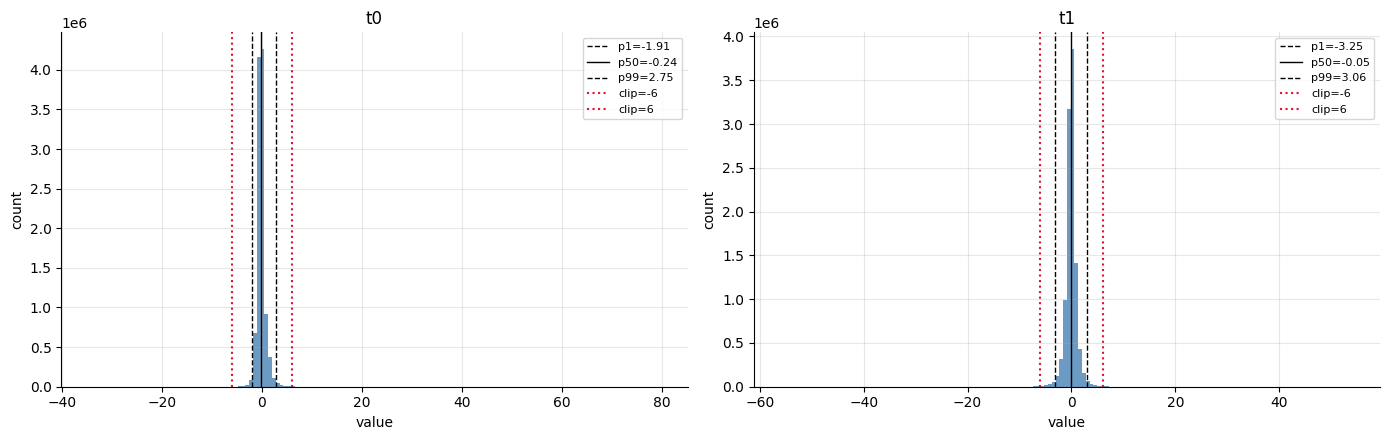

In [5]:
target_stats = feature_stats(df, TARGETS)
display(target_stats)
plot_target_distributions(df)
plt.show()

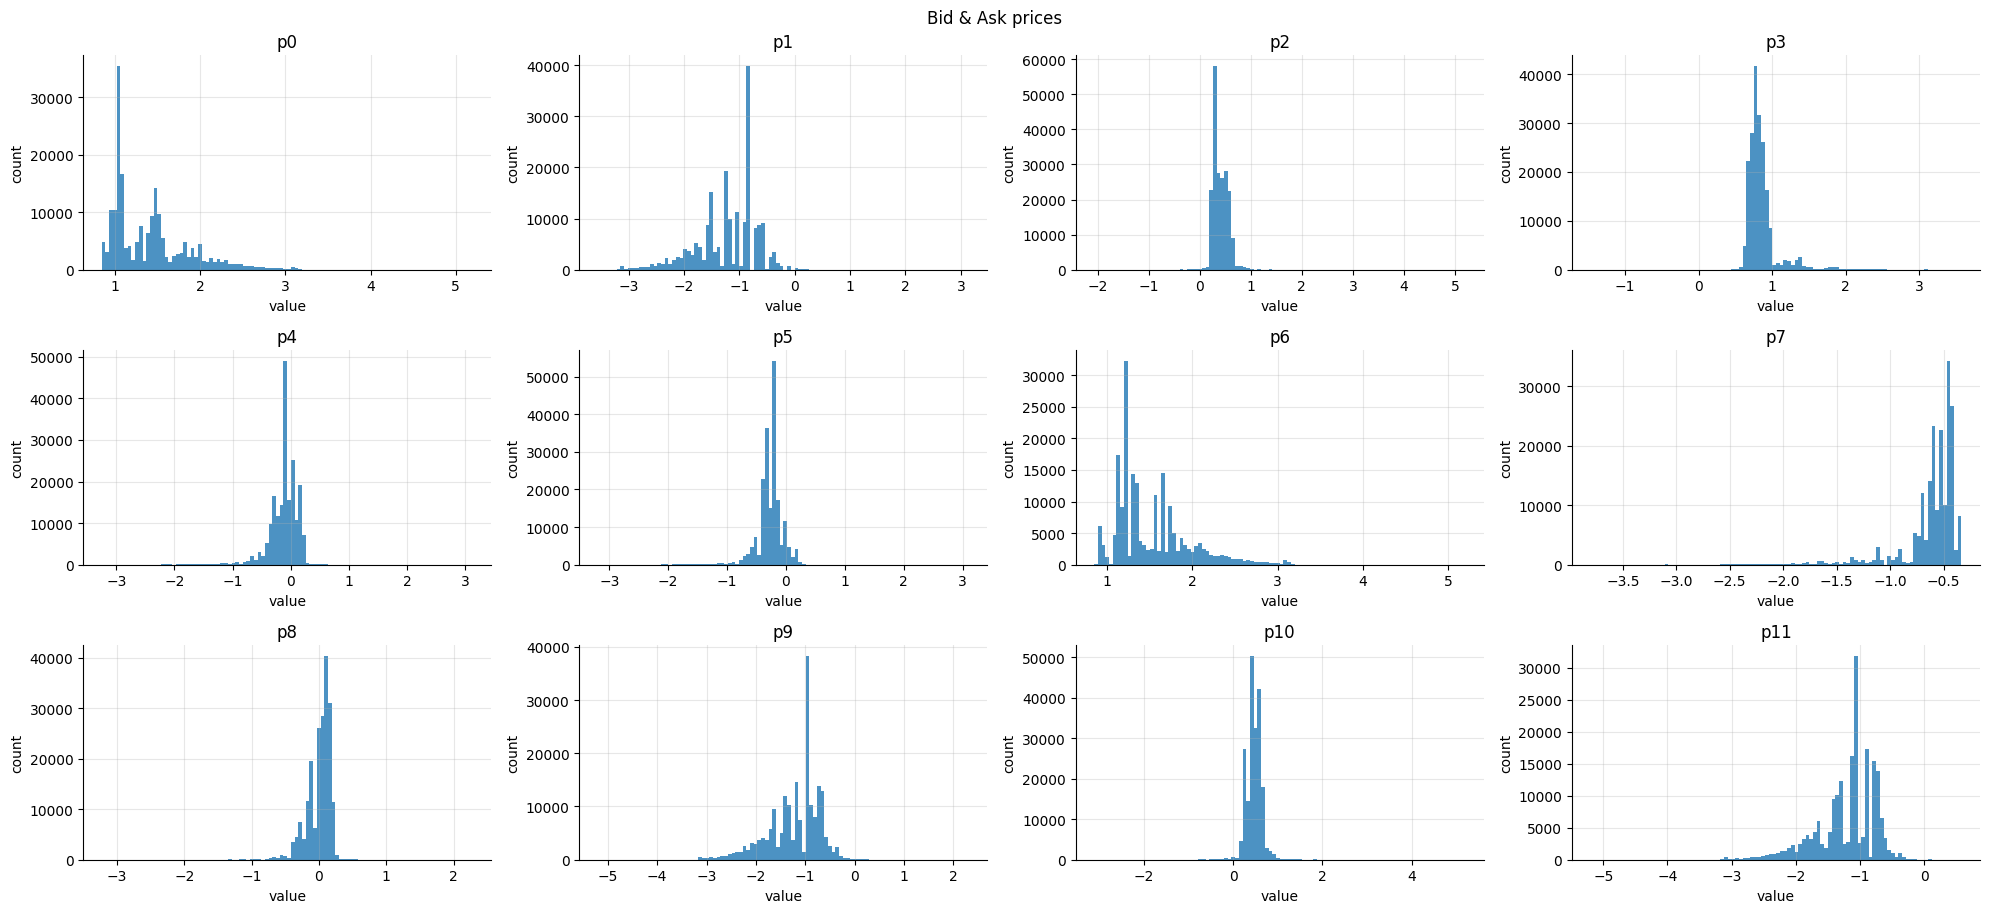

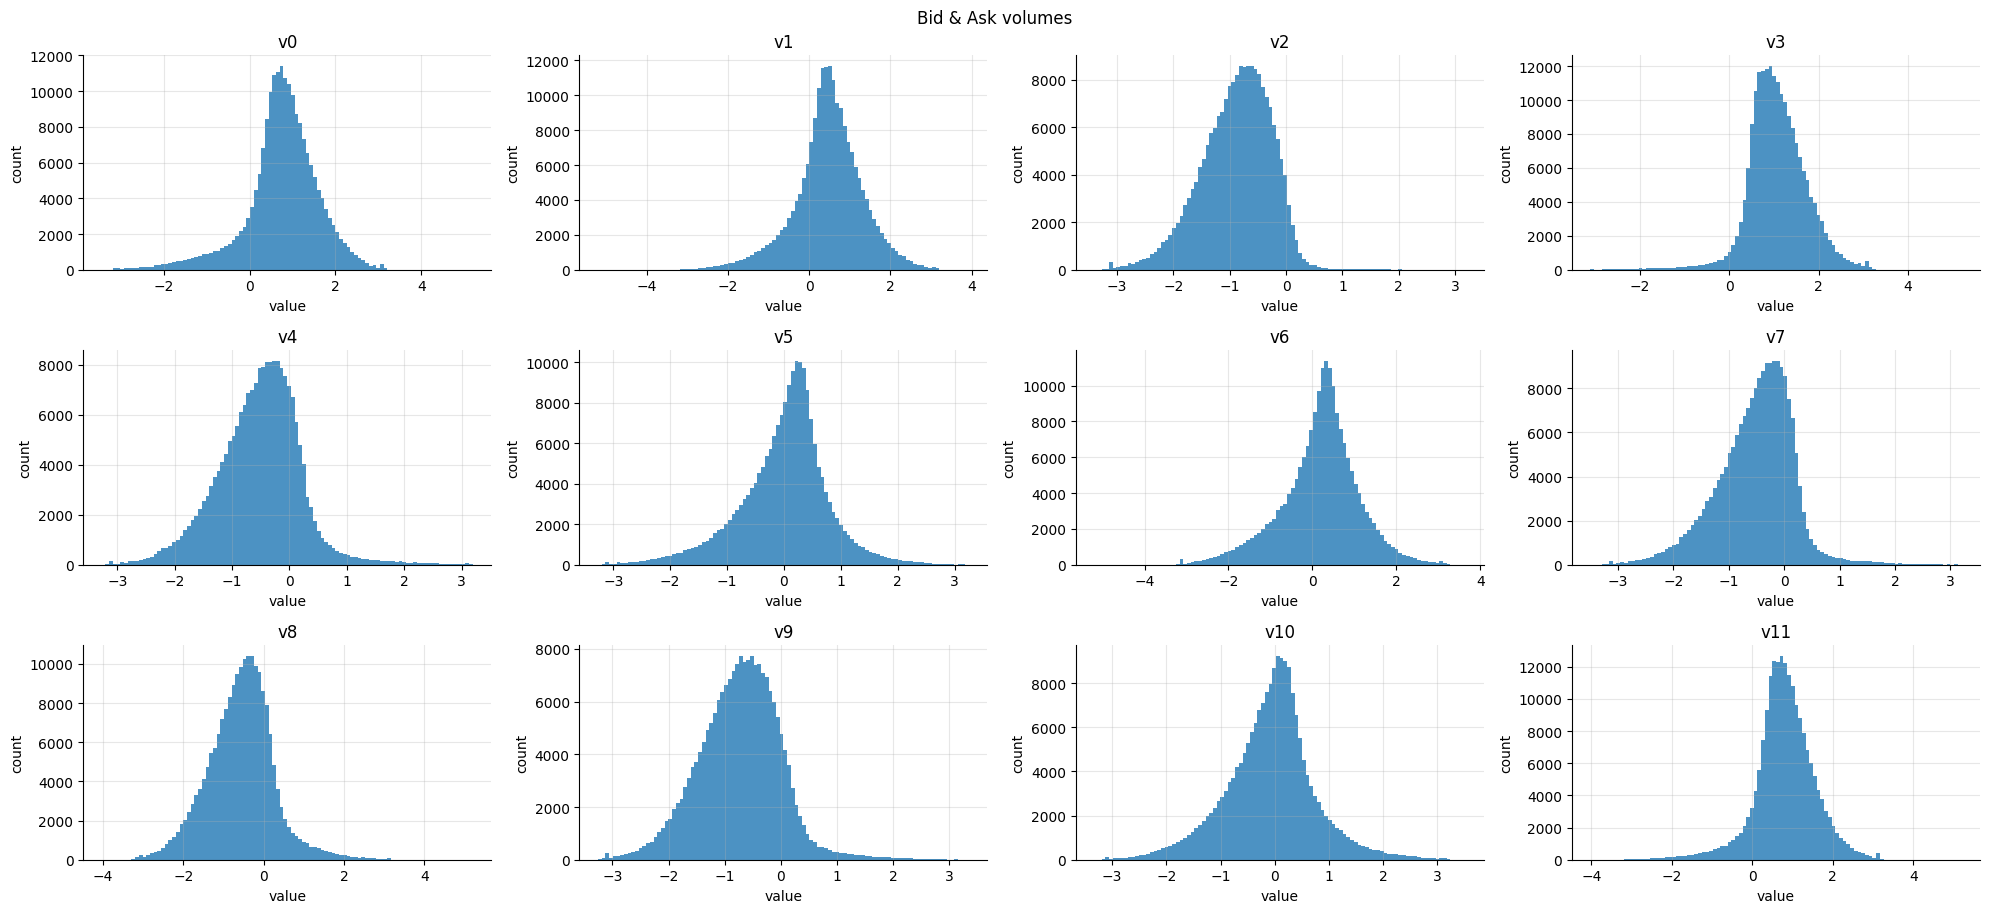

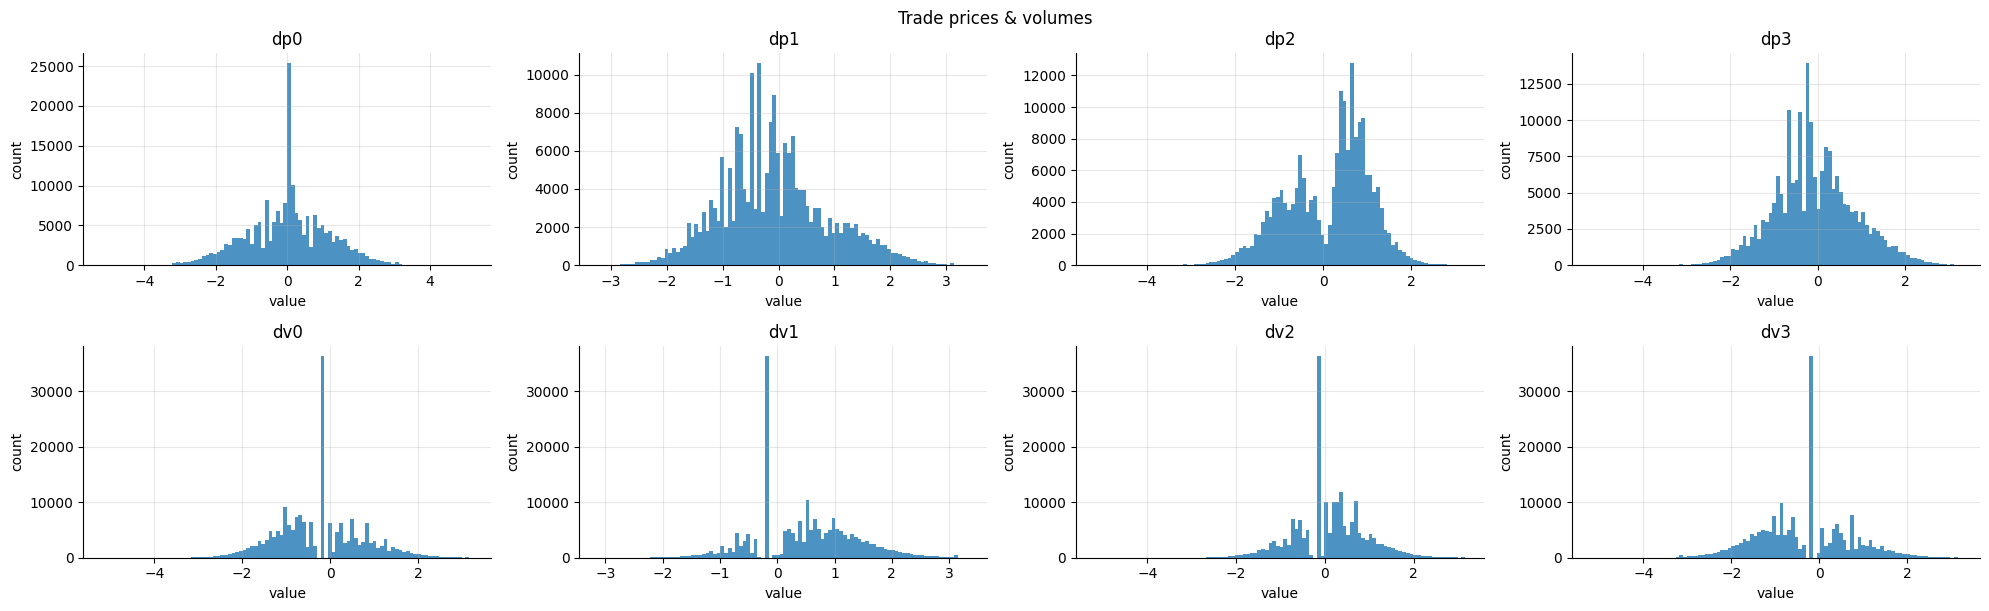

In [6]:
plot_distributions(df, BID_PRICES + ASK_PRICES, sample=200_000)
plt.suptitle("Bid & Ask prices", y=1.01)
plt.show()

plot_distributions(df, BID_VOLUMES + ASK_VOLUMES, sample=200_000)
plt.suptitle("Bid & Ask volumes", y=1.01)
plt.show()

plot_distributions(df, TRADE_PRICES + TRADE_VOLUMES, sample=200_000)
plt.suptitle("Trade prices & volumes", y=1.01)
plt.show()

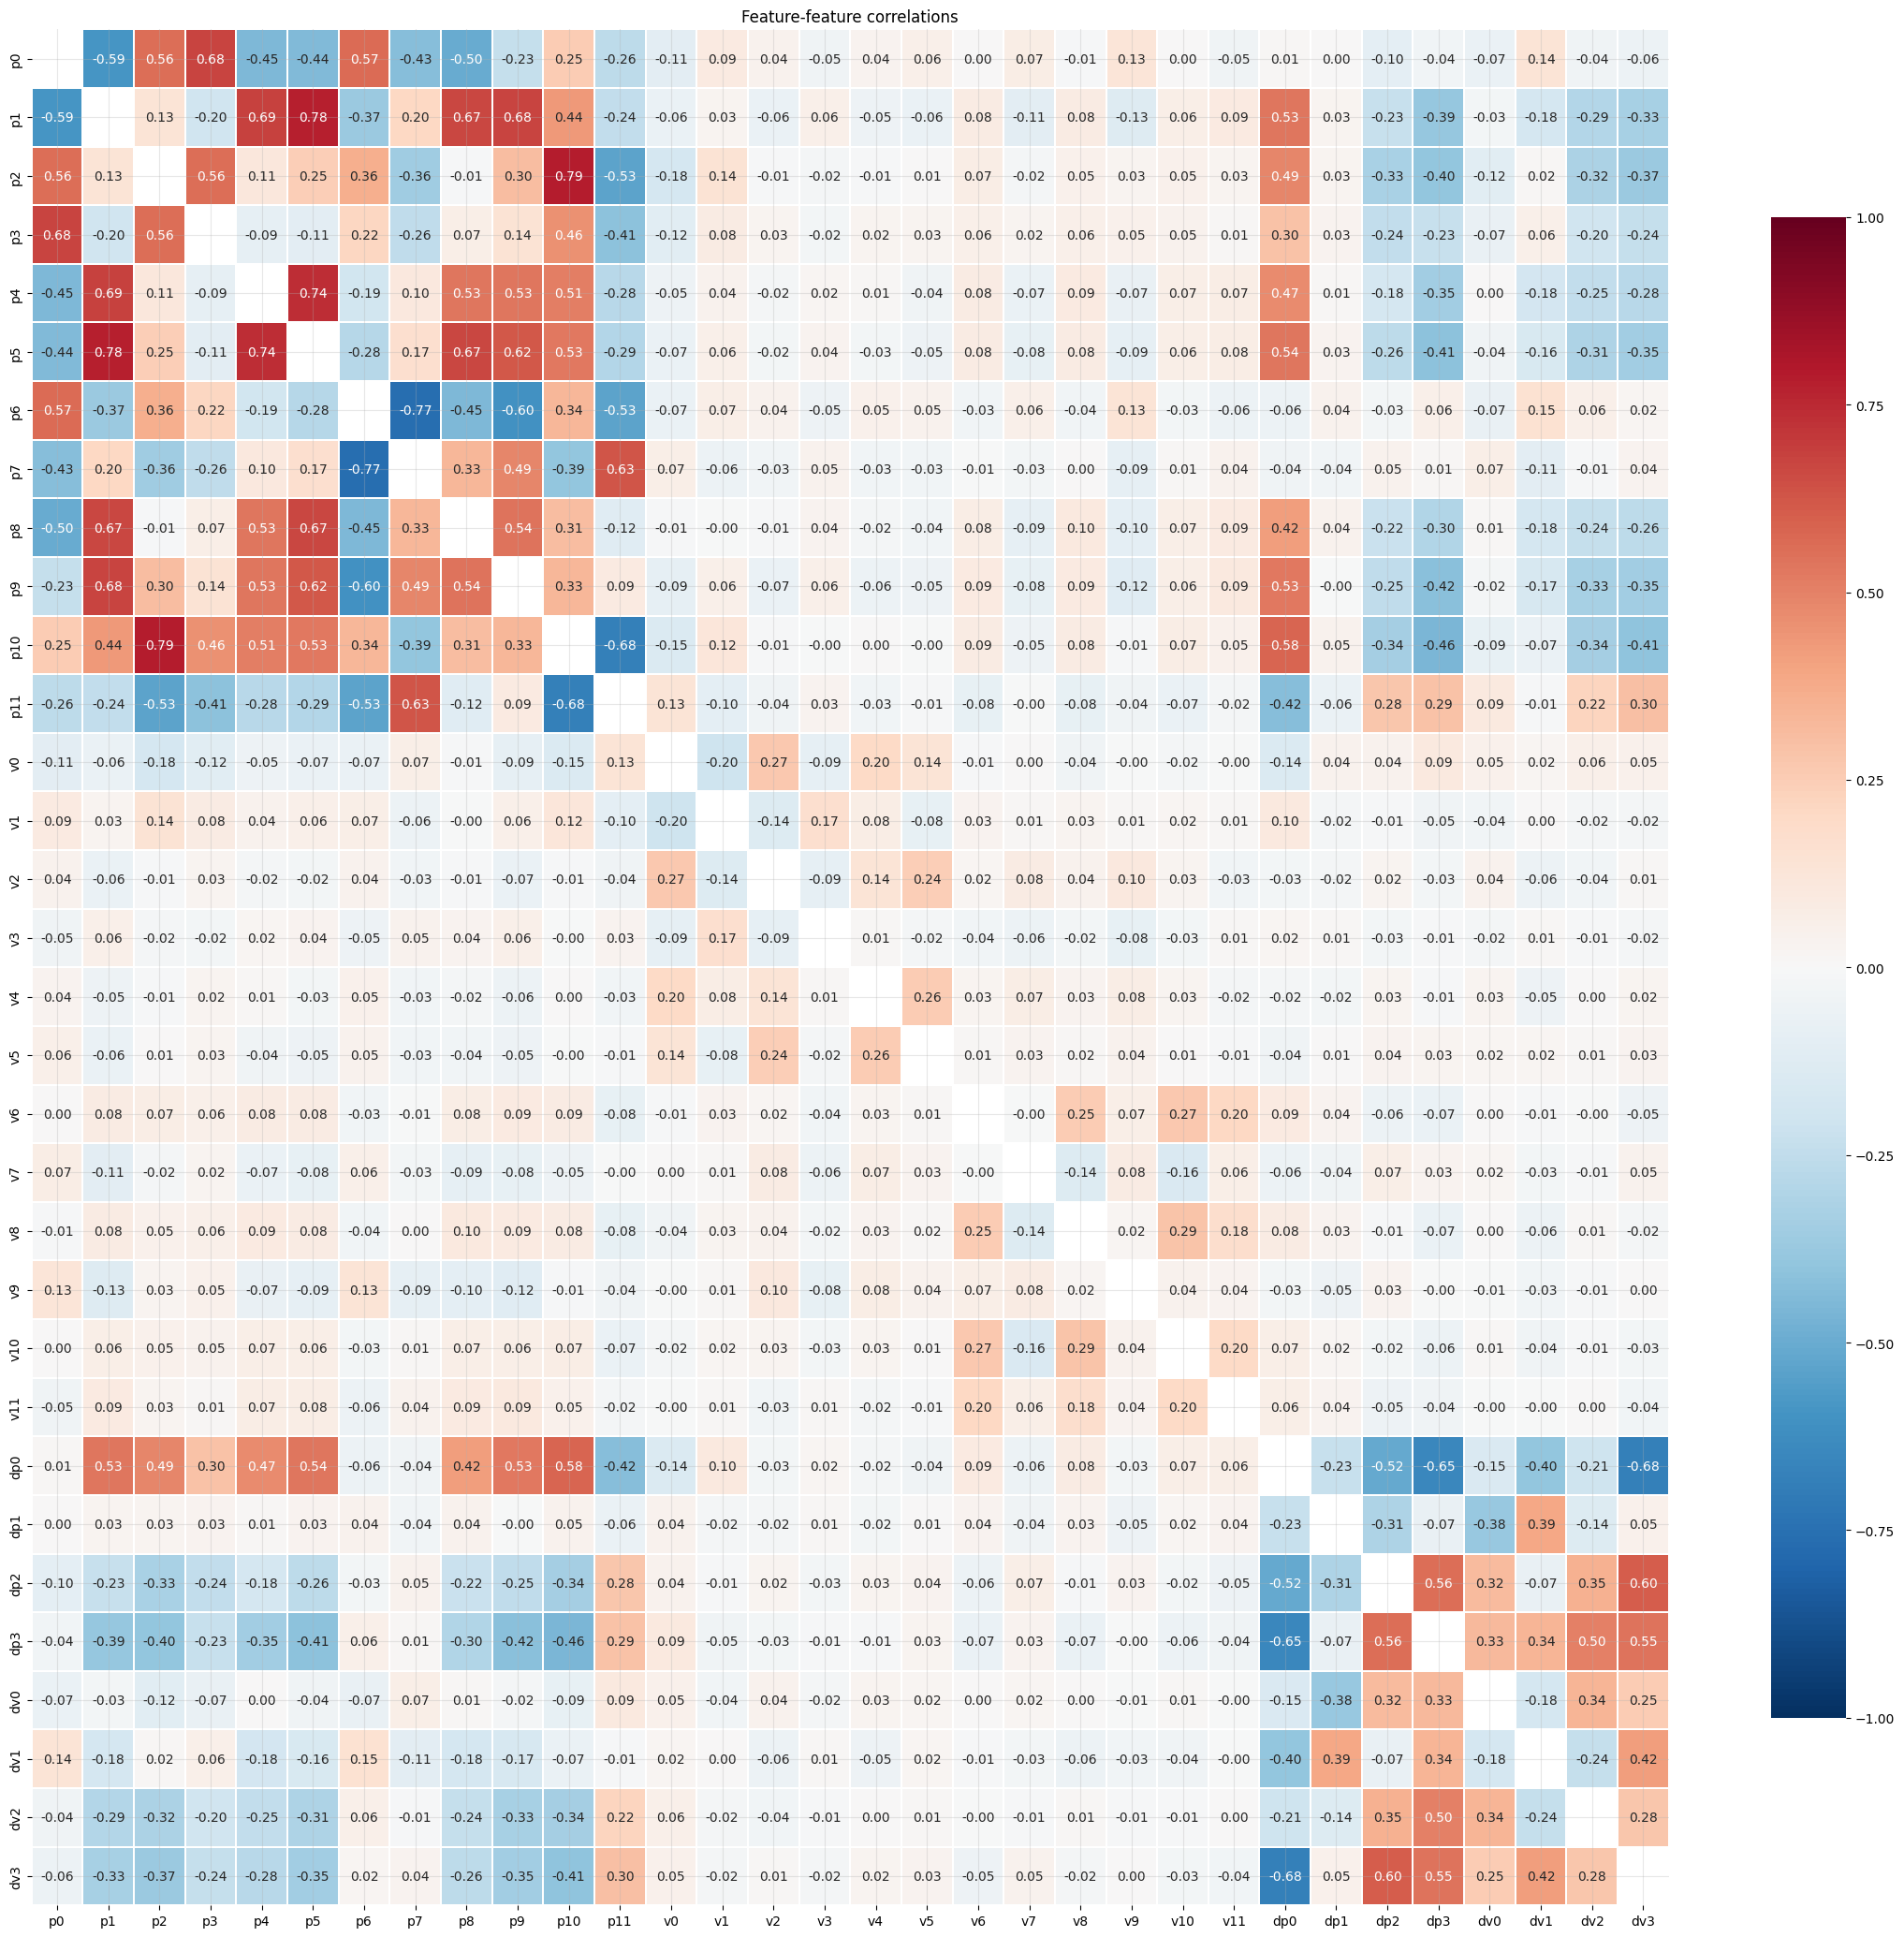

In [7]:
corr = correlation_matrix(df, ALL_FEATURES)
plot_correlation_heatmap(corr)
plt.title("Feature-feature correlations")
plt.show()

Features most correlated with t0:


t0     1.000000
t1     0.505823
p0     0.133438
p2     0.105934
p8     0.098285
v8     0.096595
v2     0.068826
p1     0.067763
dv3    0.066960
dv2    0.064633
Name: t0, dtype: float64


Features most correlated with t1:


t1     1.000000
t0     0.505823
v8     0.035376
v0     0.030290
dv3    0.029925
v1     0.029854
v2     0.026716
dp2    0.025893
dv2    0.025690
v6     0.022079
Name: t1, dtype: float64

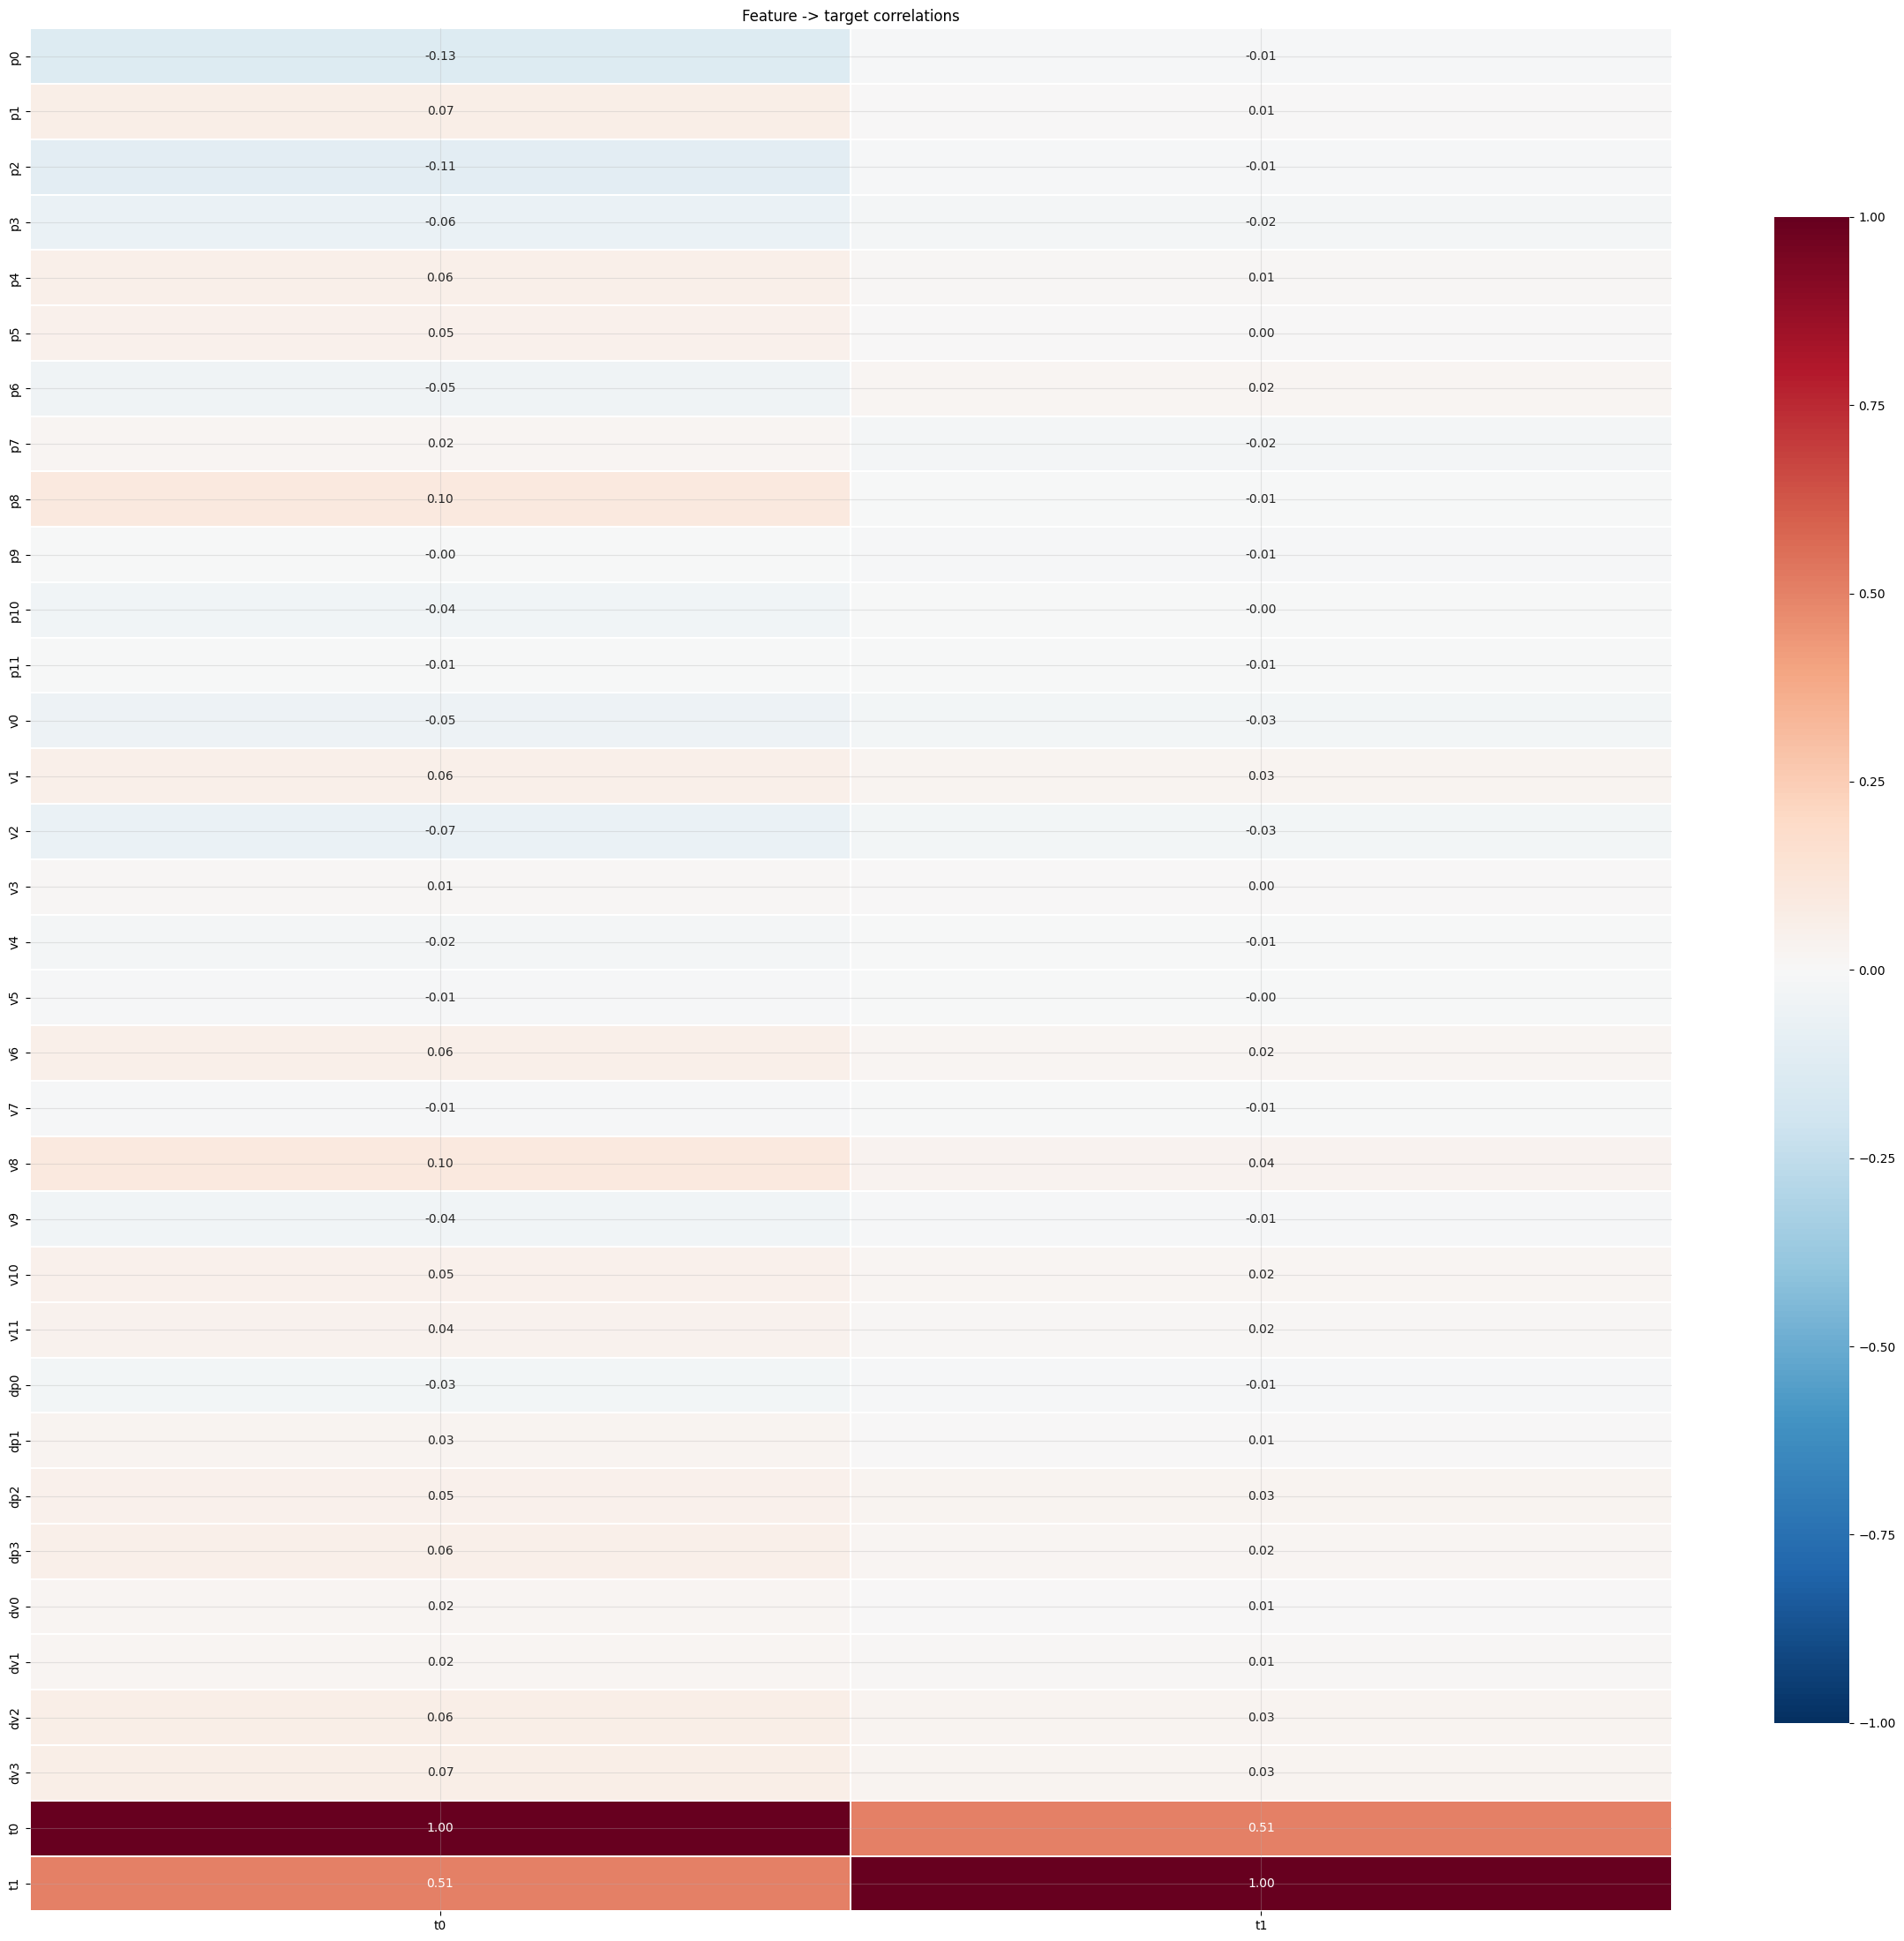

In [9]:
ft_corr = feature_target_correlations(df, ALL_FEATURES + TARGETS, TARGETS)
print("Features most correlated with t0:")
display(ft_corr["t0"].abs().sort_values(ascending=False).head(10))
print("\nFeatures most correlated with t1:")
display(ft_corr["t1"].abs().sort_values(ascending=False).head(10))

plot_correlation_heatmap(ft_corr, mask_diagonal=False, annotate=True)
plt.title("Feature -> target correlations")
plt.show()

In [10]:
top_feat_t0 = ft_corr["t0"].abs().idxmax()
top_feat_t1 = ft_corr["t1"].abs().idxmax()
plot_feature_target_scatter(df, top_feat_t0, "t0")
plt.show()
plot_feature_target_scatter(df, top_feat_t1, "t1")
plt.show()

ValueError: The truth value of a DataFrame is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

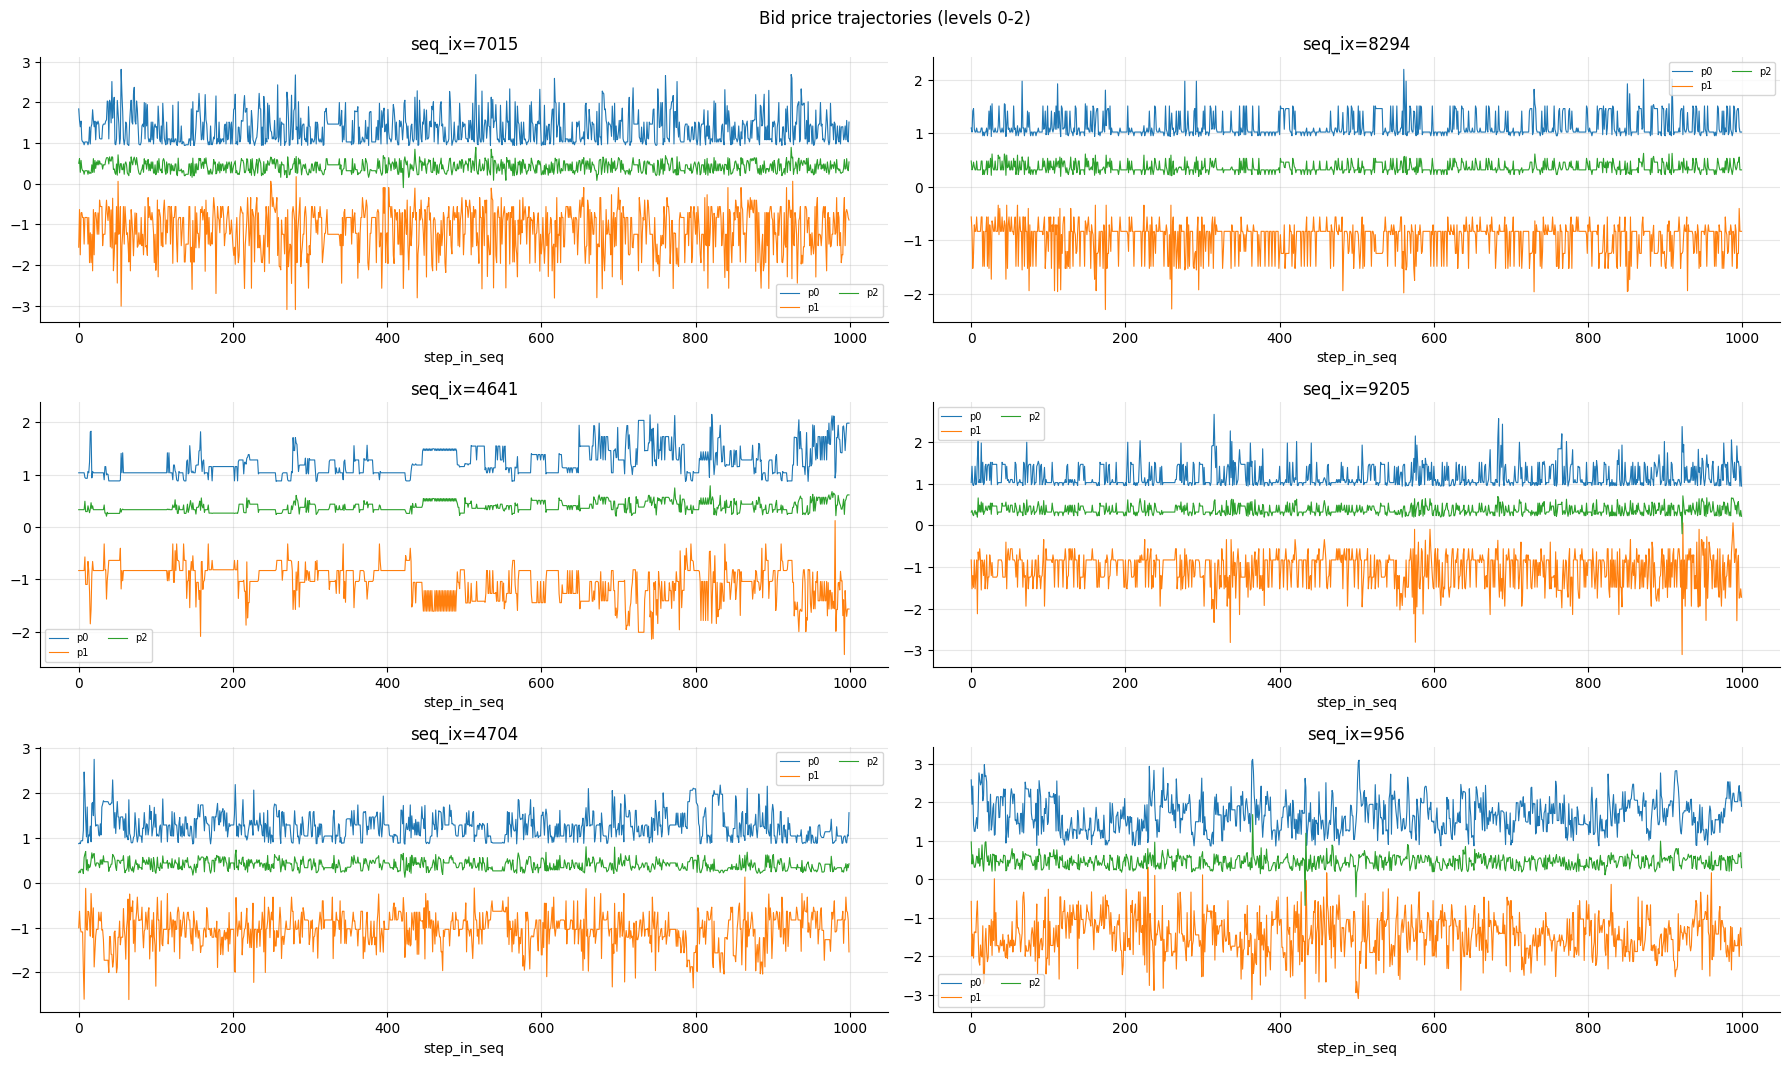

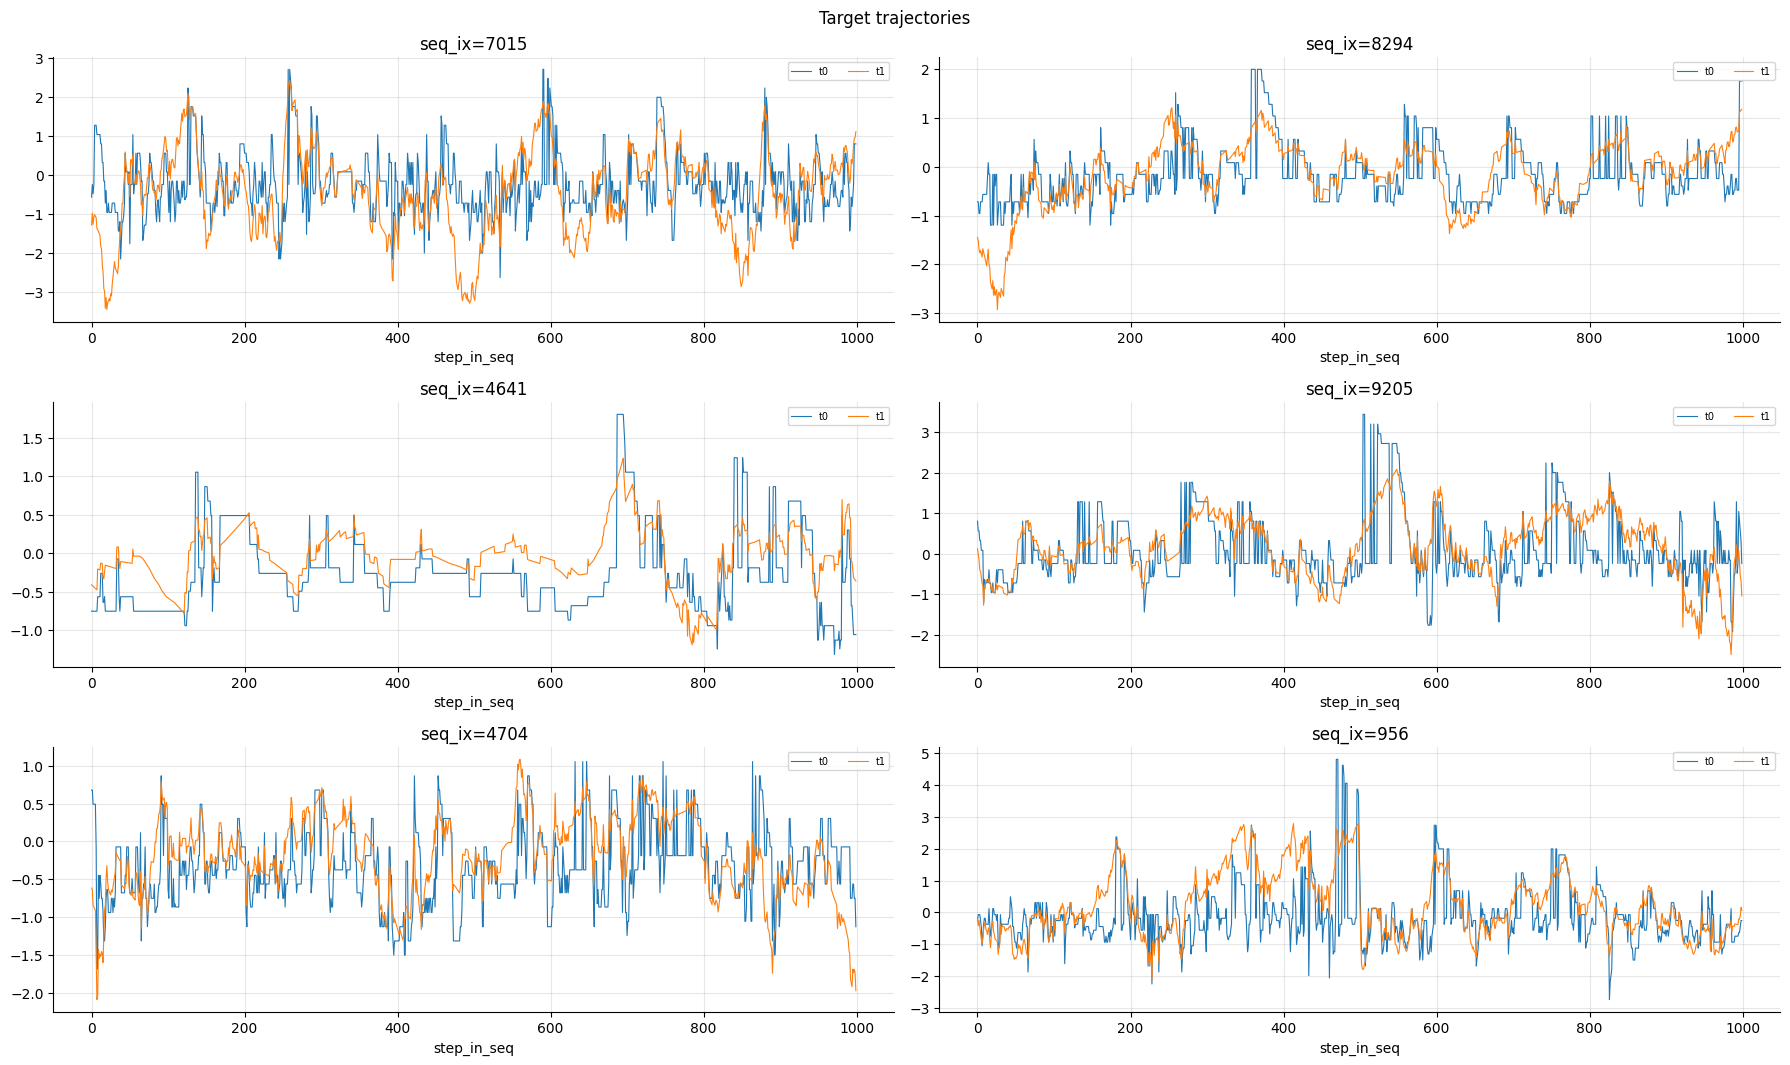

In [11]:
sampled_seqs = sample_sequences(df, n=6)
plot_feature_trajectories(df, BID_PRICES[:3], sampled_seqs)
plt.suptitle("Bid price trajectories (levels 0-2)", y=1.01)
plt.show()

plot_feature_trajectories(df, TARGETS, sampled_seqs)
plt.suptitle("Target trajectories", y=1.01)
plt.show()

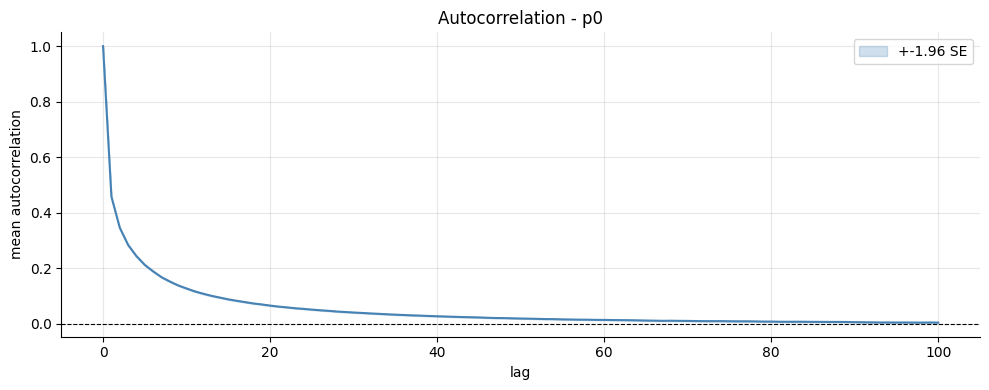

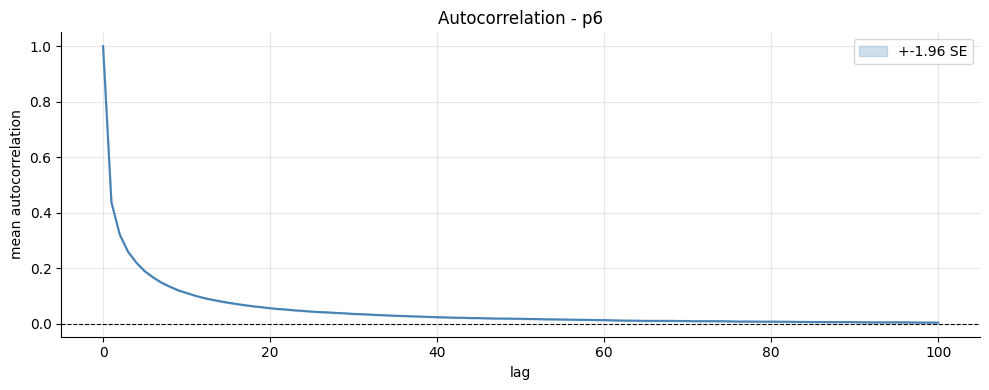

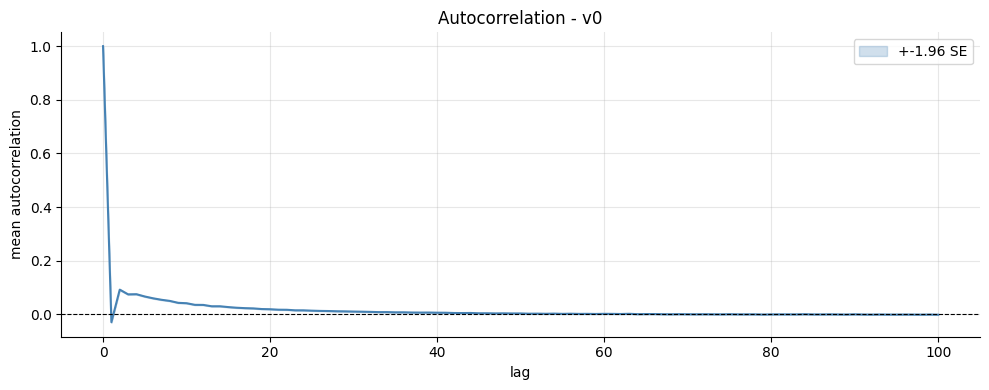

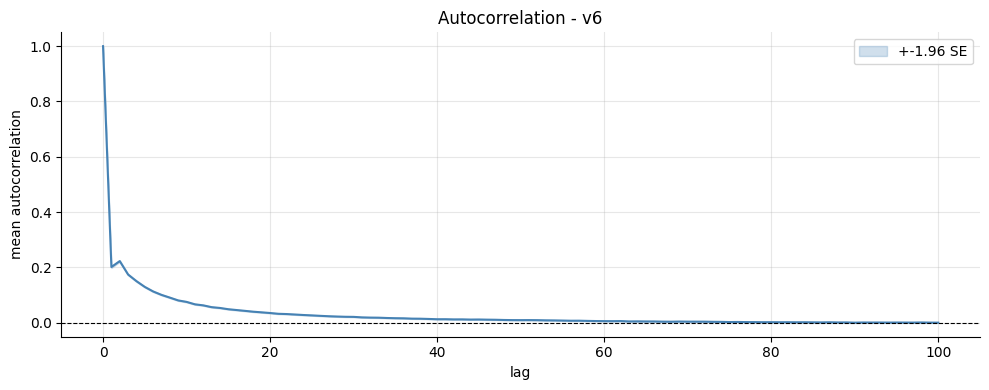

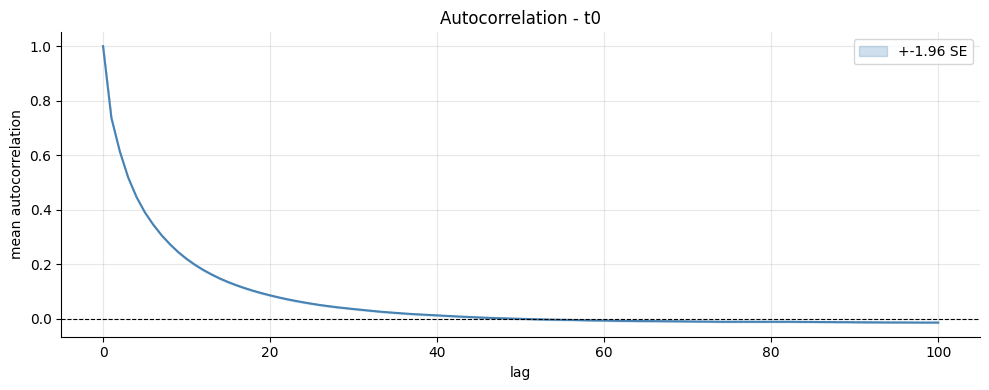

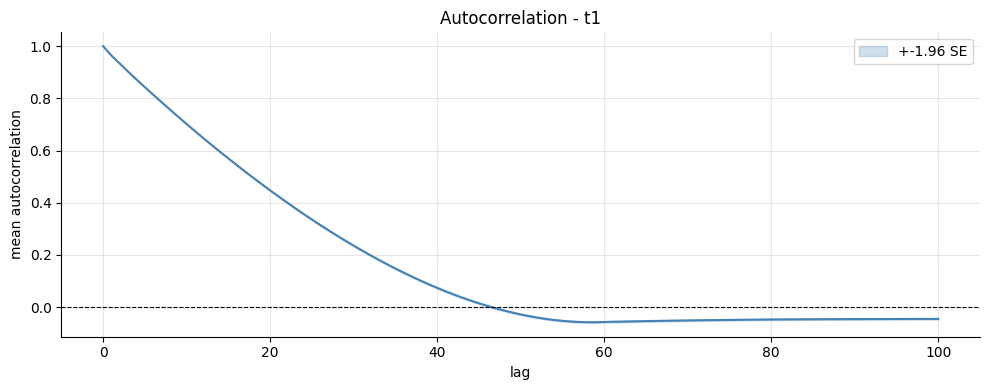

In [13]:
for col in ["p0", "p6", "v0", "v6", "t0", "t1"]:
    acf = autocorrelation(df, col, max_lag=100)
    plot_autocorrelation(acf, col)
    plt.show()

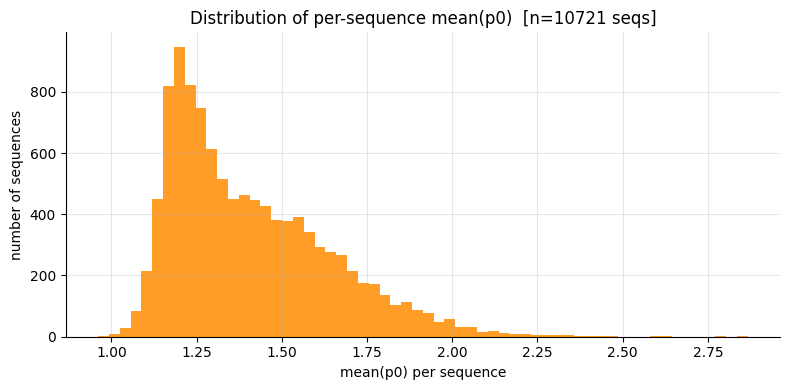

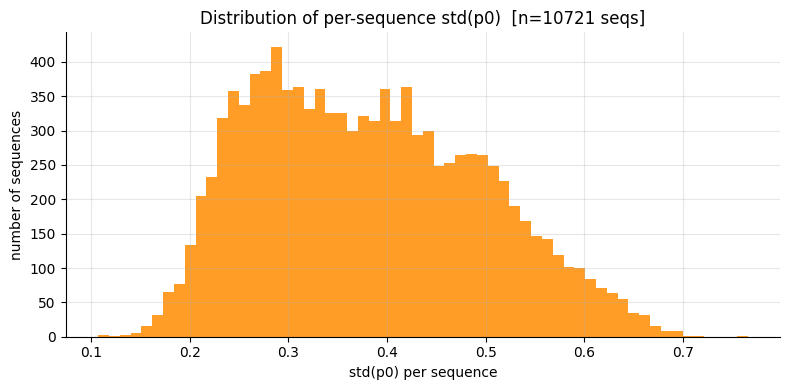

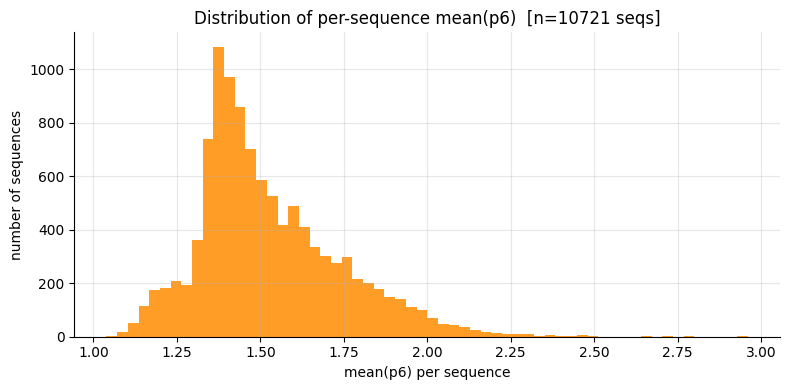

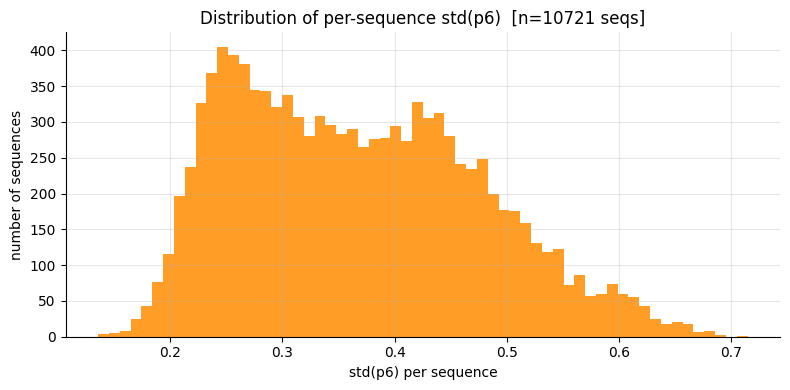

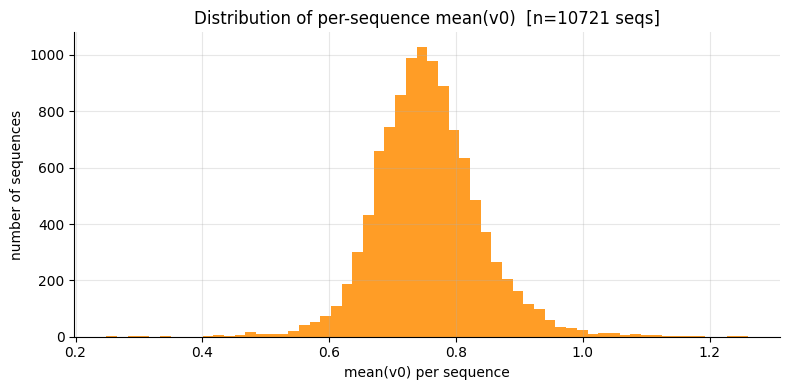

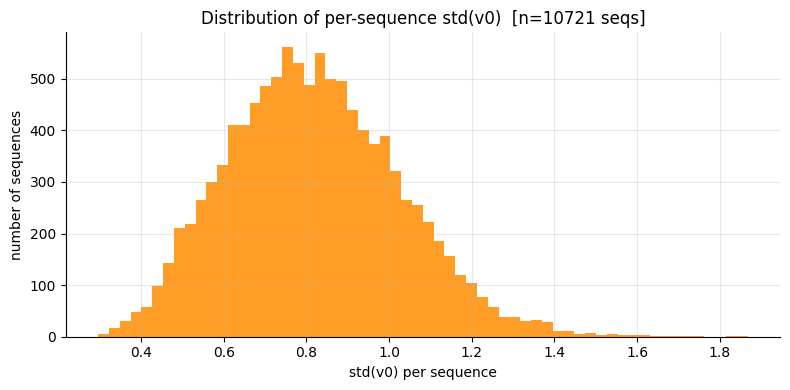

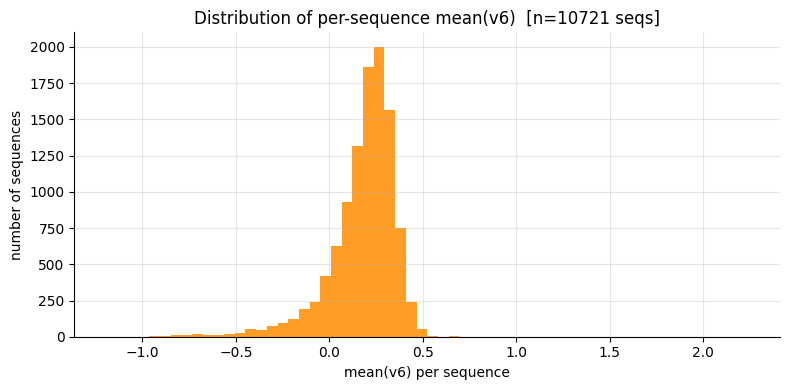

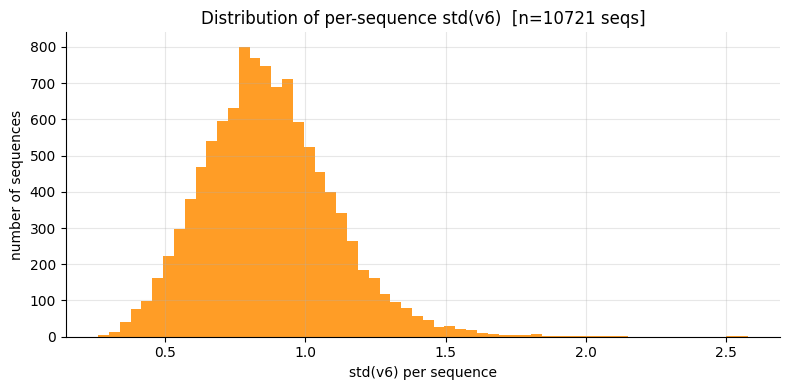

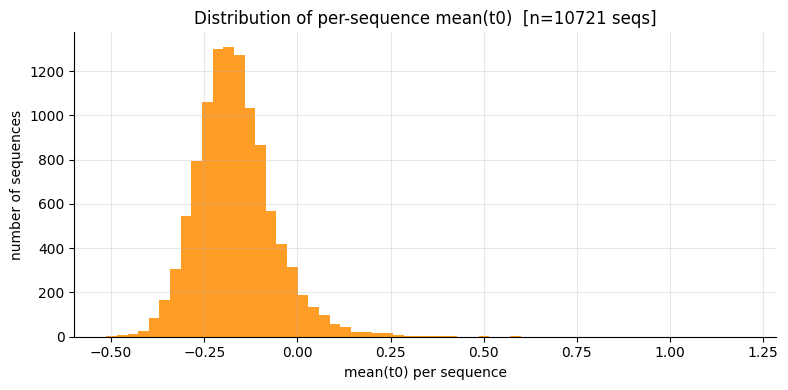

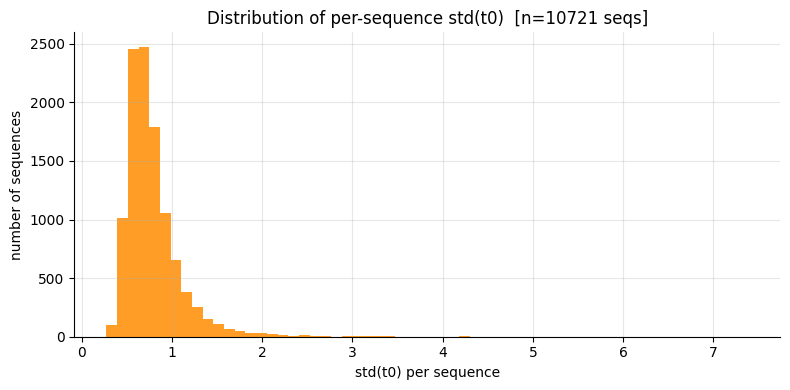

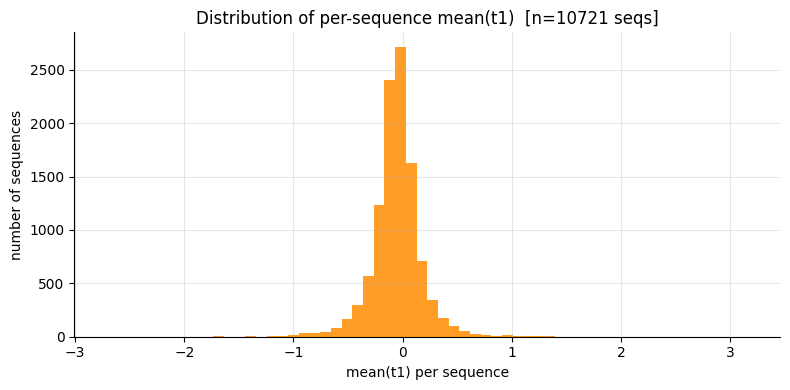

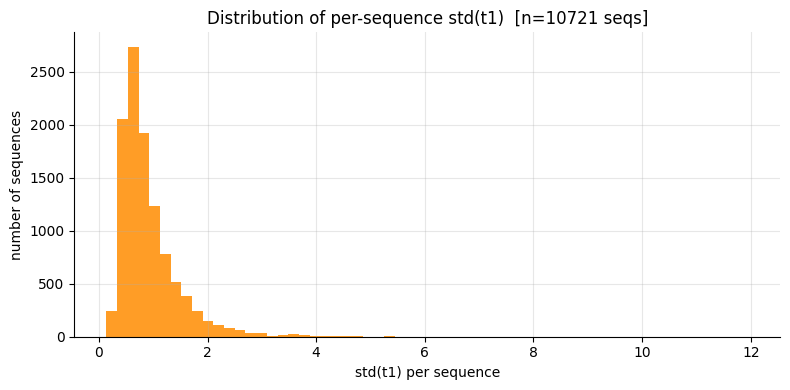

In [14]:
for col in ["p0", "p6", "v0", "v6", "t0", "t1"]:
    for agg in ["mean", "std"]:
        stat = per_sequence_stat(df, col, agg=agg)
        plot_per_sequence_stat_distribution(stat, col, agg)
        plt.show()